# Movie Data Exploration and Preparation

This notebook loads MovieLens ratings, enriches the movie catalog with
TMDB metadata, checks data quality, and explores the signals later used
by the recommendation engines. The TMDB responses are cached so repeated
runs do not download metadata that is already available.

In [63]:
import os
import pandas as pd
import requests
import time
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from getpass import getpass

def find_project_root(start_path):
    """Find the repository root when Jupyter starts inside the project."""

    start_path = Path(start_path).resolve()

    for candidate in (start_path, *start_path.parents):
        raw_data = candidate / "data" / "raw"
        if (raw_data / "movies.csv").exists() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Start Jupyter from the project root or notebooks folder."
    )


# Resolve every file from the repository root instead of a machine-specific
# absolute path. This works when Jupyter starts from either the project root
# or the notebooks directory.
PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
NOTEBOOK_PROCESSED_DIR = PROJECT_ROOT / "notebooks" / "data" / "processed"

# Load the four MovieLens source tables. Ratings and movies drive the
# model; links map MovieLens IDs to TMDB IDs; tags are retained for possible
# future feature engineering.
movies = pd.read_csv(RAW_DATA_DIR / "movies.csv")
ratings = pd.read_csv(RAW_DATA_DIR / "ratings.csv")
links = pd.read_csv(RAW_DATA_DIR / "links.csv")
tags = pd.read_csv(RAW_DATA_DIR / "tags.csv")

In [64]:
print(movies.shape)
print(ratings.shape)

print(movies.head())
print(ratings.head())

(9742, 3)
(100836, 4)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [65]:
# Create the central rating-level table: one row per user/movie rating.
movie_ratings = ratings.merge(
    movies,
    on="movieId",
    how="left"
)

In [66]:
# Convert Unix seconds to timestamps for chronological analysis.
movie_ratings["watch_date"] = pd.to_datetime(
    movie_ratings["timestamp"],
    unit="s"
)

In [67]:
print(movie_ratings.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres          watch_date  
0  Adventure|Animation|Children|Comedy|Fantasy 2000-07-30 18:45:03  
1                               Comedy|Romance 2000-07-30 18:20:47  
2                        Action|Crime|Thriller 2000-07-30 18:37:04  
3                             Mystery|Thriller 2000-07-30 19:03:35  
4                       Crime|Mystery|Thriller 2000-07-30 18:48:51  


In [68]:
# Attach the external TMDB identifier used by the enrichment request.
movie_ratings = movie_ratings.merge(
    links[["movieId", "tmdbId"]],
    on="movieId",
    how="left"
)

In [69]:
movie_ratings["tmdbId"] = pd.to_numeric(
    movie_ratings["tmdbId"],
    errors="coerce"
).astype("Int64")

In [70]:
movie_ratings[
    ["userId", "movieId", "title", "rating", "tmdbId"]
].head()

,userId,movieId,title,rating,tmdbId
0,1,1,Toy Story (1995),4.0,862
1,1,3,Grumpier Old Men (1995),4.0,15602
2,1,6,Heat (1995),4.0,949
3,1,47,Seven (a.k.a. Se7en) (1995),5.0,807
4,1,50,"Usual Suspects, The (1995)",5.0,629


In [71]:
unique_tmdb_ids = (
    movie_ratings["tmdbId"]
    .dropna()
    .astype(int)
    .unique()
)

print(f"Movie rating rows: {len(movie_ratings):,}")
print(f"Unique TMDB movies: {len(unique_tmdb_ids):,}")

Movie rating rows: 100,836
Unique TMDB movies: 9,715


In [ ]:
# Cache downloaded metadata locally because thousands of API calls are
# slow and subject to rate limits.
TMDB_CACHE = PROJECT_ROOT / "data" / "processed" / "tmdb_movies.csv"

TMDB_CACHE.parent.mkdir(
    parents=True,
    exist_ok=True
)

print(f"TMDB cache location: {TMDB_CACHE}")

In [73]:
if TMDB_CACHE.exists():
    
    tmdb_movies = pd.read_csv(
        TMDB_CACHE
    )
    
    print(
        f"Cached TMDB data found: "
        f"{len(tmdb_movies):,} movies"
    )

else:
    
    tmdb_movies = pd.DataFrame()
    
    print("No cached TMDB data found yet.")

Cached TMDB data found: 9,715 movies


In [74]:
if not tmdb_movies.empty:

    tmdb_movies["tmdbId"] = pd.to_numeric(
        tmdb_movies["tmdbId"],
        errors="coerce"
    )

    if "tmdb_status" in tmdb_movies.columns:

        completed_ids = set(
            tmdb_movies.loc[
                tmdb_movies["tmdb_status"].isin(
                    ["ok", "not_found"]
                ),
                "tmdbId"
            ]
            .dropna()
            .astype(int)
        )

    else:

        completed_ids = set(
            tmdb_movies["tmdbId"]
            .dropna()
            .astype(int)
        )

else:

    completed_ids = set()


remaining_ids = [
    tmdb_id
    for tmdb_id in unique_tmdb_ids
    if tmdb_id not in completed_ids
]


print(f"Already completed: {len(completed_ids):,}")
print(f"Still to download: {len(remaining_ids):,}")

Already completed: 9,715
Still to download: 0


In [75]:
def get_tmdb_movie(tmdb_id, session, max_retries=3):
    """
    Download metadata for one movie from TMDB.
    
    Returns movie information including:
    title, director, genres, release date, runtime,
    language, rating, popularity and overview.
    """

    url = (
        f"https://api.themoviedb.org/3/movie/"
        f"{int(tmdb_id)}"
    )

    params = {
        "language": "en-US",
        "append_to_response": "credits"
    }

    for attempt in range(1, max_retries + 1):

        try:

            response = session.get(
                url,
                params=params,
                timeout=30
            )

            # TMDB rate limit
            if response.status_code == 429:

                wait_time = int(
                    response.headers.get(
                        "Retry-After",
                        2
                    )
                )

                print(
                    f"Rate limit reached. "
                    f"Waiting {wait_time} seconds..."
                )

                time.sleep(wait_time)

                continue

            # Movie no longer exists / unavailable
            if response.status_code == 404:

                return {
                    "tmdbId": int(tmdb_id),
                    "tmdb_status": "not_found"
                }

            response.raise_for_status()

            data = response.json()

            # -----------------------------
            # Director
            # -----------------------------

            crew = (
                data
                .get("credits", {})
                .get("crew", [])
            )

            directors = [
                person["name"]
                for person in crew
                if person.get("job") == "Director"
                and person.get("name")
            ]

            # -----------------------------
            # Genres
            # -----------------------------

            tmdb_genres = [
                genre["name"]
                for genre in data.get(
                    "genres",
                    []
                )
                if genre.get("name")
            ]

            # -----------------------------
            # Return selected data
            # -----------------------------

            return {
                "tmdbId": int(tmdb_id),
                "tmdb_status": "ok",

                "tmdb_title":
                    data.get("title"),

                "original_title":
                    data.get("original_title"),

                "director":
                    " | ".join(directors),

                "tmdb_genres":
                    " | ".join(tmdb_genres),

                "release_date":
                    data.get("release_date"),

                "runtime":
                    data.get("runtime"),

                "original_language":
                    data.get("original_language"),

                "tmdb_rating":
                    data.get("vote_average"),

                "tmdb_vote_count":
                    data.get("vote_count"),

                "popularity":
                    data.get("popularity"),

                "overview":
                    data.get("overview")
            }

        except requests.RequestException as error:

            print(
                f"Attempt {attempt}/{max_retries} "
                f"failed for TMDB ID {tmdb_id}: "
                f"{error}"
            )

            if attempt < max_retries:
                time.sleep(2)

    return {
        "tmdbId": int(tmdb_id),
        "tmdb_status": "error"
    }

In [76]:
TMDB_TOKEN = None

if len(remaining_ids) > 0:

    TMDB_TOKEN = os.getenv(
        "TMDB_TOKEN"
    )

    if not TMDB_TOKEN:

        TMDB_TOKEN = getpass(
            "Enter your TMDB API Read Access Token: "
        )

    print("TMDB authentication ready.")

else:

    print(
        "All TMDB data is already cached. "
        "No API token is needed."
    )

All TMDB data is already cached. No API token is needed.


In [77]:
# Test the TMDB connection with one movie

if len(remaining_ids) > 0:

    test_session = requests.Session()

    test_session.headers.update({
        "Authorization": f"Bearer {TMDB_TOKEN}",
        "accept": "application/json"
    })

    test_tmdb_id = remaining_ids[0]

    print(f"Testing TMDB ID: {test_tmdb_id}")

    test_movie = get_tmdb_movie(
        test_tmdb_id,
        test_session
    )

    test_session.close()

    print("\nTMDB response:")
    display(test_movie)

else:

    print(
        "No download test needed because "
        "all TMDB movies are already cached."
    )

No download test needed because all TMDB movies are already cached.


In [78]:
if len(remaining_ids) > 0:

    session = requests.Session()

    session.headers.update({
        "Authorization": f"Bearer {TMDB_TOKEN}",
        "accept": "application/json"
    })

    newly_downloaded = []

    for i, tmdb_id in enumerate(
        remaining_ids,
        start=1
    ):

        movie_data = get_tmdb_movie(
            tmdb_id,
            session
        )

        newly_downloaded.append(
            movie_data
        )


        # Save every 100 movies
        if i % 100 == 0:

            new_df = pd.DataFrame(
                newly_downloaded
            )

            tmdb_movies = pd.concat(
                [
                    tmdb_movies,
                    new_df
                ],
                ignore_index=True
            )

            tmdb_movies = (
                tmdb_movies
                .drop_duplicates(
                    subset="tmdbId",
                    keep="last"
                )
            )

            tmdb_movies.to_csv(
                TMDB_CACHE,
                index=False
            )

            newly_downloaded = []

            print(
                f"Downloaded {i:,} / "
                f"{len(remaining_ids):,}"
            )


    # Add whatever remains after the last batch of 100
    if newly_downloaded:

        new_df = pd.DataFrame(
            newly_downloaded
        )

        tmdb_movies = pd.concat(
            [
                tmdb_movies,
                new_df
            ],
            ignore_index=True
        )


    tmdb_movies = (
        tmdb_movies
        .drop_duplicates(
            subset="tmdbId",
            keep="last"
        )
    )


    tmdb_movies.to_csv(
        TMDB_CACHE,
        index=False
    )

    session.close()

    print("\nDownload finished.")

else:

    print(
        "TMDB dataset already complete. "
        "No download necessary."
    )

TMDB dataset already complete. No download necessary.


In [79]:
print(
    f"TMDB movies stored: "
    f"{len(tmdb_movies):,}"
)

tmdb_movies.head()

TMDB movies stored: 9,715


,tmdbId,tmdb_status,tmdb_title,original_title,director,tmdb_genres,release_date,runtime,original_language,tmdb_rating,tmdb_vote_count,popularity,overview
0,862,ok,Toy Story,Toy Story,John Lasseter,Family | Comedy | Animation | Adventure,1995-11-22,81.0,en,8.000,20304.0,41.0572,"Led by Woody, Andy's toys live happily in his ..."
1,15602,ok,Grumpier Old Men,Grumpier Old Men,Howard Deutch,Romance | Comedy,1995-12-22,101.0,en,6.466,436.0,5.9315,A family wedding reignites the ancient feud be...
2,949,ok,Heat,Heat,Michael Mann,Crime | Drama | Action,1995-12-15,170.0,en,7.941,8555.0,23.1580,Obsessive master thief Neil McCauley leads a t...
3,807,ok,Se7en,Se7en,David Fincher,Crime | Mystery | Thriller,1995-09-22,127.0,en,8.380,23515.0,33.8713,Two homicide detectives are on a desperate hun...
4,629,ok,The Usual Suspects,The Usual Suspects,Bryan Singer,Drama | Crime | Thriller,1995-07-19,106.0,en,8.165,11603.0,21.1306,"Held in an L.A. interrogation room, Verbal Kin..."


In [80]:
tmdb_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9715 entries, 0 to 9714
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tmdbId             9715 non-null   int64  
 1   tmdb_status        9715 non-null   str    
 2   tmdb_title         9602 non-null   str    
 3   original_title     9602 non-null   str    
 4   director           9598 non-null   str    
 5   tmdb_genres        9601 non-null   str    
 6   release_date       9602 non-null   str    
 7   runtime            9602 non-null   float64
 8   original_language  9602 non-null   str    
 9   tmdb_rating        9602 non-null   float64
 10  tmdb_vote_count    9602 non-null   float64
 11  popularity         9602 non-null   float64
 12  overview           9601 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 986.8 KB


In [81]:
tmdb_movies["tmdb_status"].value_counts()

tmdb_status
ok           9602
not_found     113
Name: count, dtype: int64

In [82]:
tmdb_movies["tmdbId"] = pd.to_numeric(
    tmdb_movies["tmdbId"],
    errors="coerce"
).astype("Int64")


tmdb_movies["release_date"] = pd.to_datetime(
    tmdb_movies["release_date"],
    errors="coerce"
)

In [83]:
tmdb_movies["release_year"] = (
    tmdb_movies["release_date"]
    .dt.year
    .astype("Int64")
)

In [84]:
tmdb_movies.head()

,tmdbId,tmdb_status,tmdb_title,original_title,director,tmdb_genres,release_date,runtime,original_language,tmdb_rating,tmdb_vote_count,popularity,overview,release_year
0,862,ok,Toy Story,Toy Story,John Lasseter,Family | Comedy | Animation | Adventure,1995-11-22,81.0,en,8.000,20304.0,41.0572,"Led by Woody, Andy's toys live happily in his ...",1995
1,15602,ok,Grumpier Old Men,Grumpier Old Men,Howard Deutch,Romance | Comedy,1995-12-22,101.0,en,6.466,436.0,5.9315,A family wedding reignites the ancient feud be...,1995
2,949,ok,Heat,Heat,Michael Mann,Crime | Drama | Action,1995-12-15,170.0,en,7.941,8555.0,23.1580,Obsessive master thief Neil McCauley leads a t...,1995
3,807,ok,Se7en,Se7en,David Fincher,Crime | Mystery | Thriller,1995-09-22,127.0,en,8.380,23515.0,33.8713,Two homicide detectives are on a desperate hun...,1995
4,629,ok,The Usual Suspects,The Usual Suspects,Bryan Singer,Drama | Crime | Thriller,1995-07-19,106.0,en,8.165,11603.0,21.1306,"Held in an L.A. interrogation room, Verbal Kin...",1995


In [85]:
tmdb_movies[
    [
        "tmdb_title",
        "director",
        "tmdb_genres",
        "release_year",
        "runtime",
        "tmdb_rating",
        "tmdb_vote_count",
        "popularity"
    ]
].head(10)

,tmdb_title,director,tmdb_genres,release_year,runtime,tmdb_rating,tmdb_vote_count,popularity
0,Toy Story,John Lasseter,Family | Comedy | Animation | Adventure,1995,81.0,8.000,20304.0,41.0572
1,Grumpier Old Men,Howard Deutch,Romance | Comedy,1995,101.0,6.466,436.0,5.9315
2,Heat,Michael Mann,Crime | Drama | Action,1995,170.0,7.941,8555.0,23.1580
3,Se7en,David Fincher,Crime | Mystery | Thriller,1995,127.0,8.380,23515.0,33.8713
4,The Usual Suspects,Bryan Singer,Drama | Crime | Thriller,1995,106.0,8.165,11603.0,21.1306
5,From Dusk Till Dawn,Robert Rodriguez,Horror | Action | Crime,1996,108.0,7.047,6614.0,11.9842
6,Bottle Rocket,Wes Anderson,Comedy | Crime | Drama,1996,91.0,6.698,1219.0,6.0763
7,Braveheart,Mel Gibson,Action | Drama | History | War,1995,178.0,7.944,11302.0,18.5026
8,Rob Roy,Michael Caton-Jones,Adventure | History | Drama | Action | War,1995,139.0,6.723,721.0,4.4796
9,Canadian Bacon,Michael Moore,Comedy,1995,91.0,5.760,260.0,2.9695


In [86]:
movie_ratings = movie_ratings.merge(
    tmdb_movies[
        [
            "tmdbId",
            "tmdb_status",
            "tmdb_title",
            "original_title",
            "director",
            "tmdb_genres",
            "release_date",
            "release_year",
            "runtime",
            "original_language",
            "tmdb_rating",
            "tmdb_vote_count",
            "popularity",
            "overview"
        ]
    ],
    on="tmdbId",
    how="left"
)

In [87]:
movie_ratings[
    [
        "userId",
        "movieId",
        "title",
        "genres",
        "director",
        "rating",
        "watch_date",
        "release_year",
        "runtime",
        "tmdb_rating",
        "popularity"
    ]
].head(10)

,userId,movieId,title,genres,director,rating,watch_date,release_year,runtime,tmdb_rating,popularity
0,1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,John Lasseter,4.0,2000-07-30 18:45:03,1995,81.0,8.000,41.0572
1,1,3,Grumpier Old Men (1995),Comedy|Romance,Howard Deutch,4.0,2000-07-30 18:20:47,1995,101.0,6.466,5.9315
2,1,6,Heat (1995),Action|Crime|Thriller,Michael Mann,4.0,2000-07-30 18:37:04,1995,170.0,7.941,23.1580
3,1,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,David Fincher,5.0,2000-07-30 19:03:35,1995,127.0,8.380,33.8713
4,1,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,Bryan Singer,5.0,2000-07-30 18:48:51,1995,106.0,8.165,21.1306
5,1,70,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller,Robert Rodriguez,3.0,2000-07-30 18:40:00,1996,108.0,7.047,11.9842
6,1,101,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance,Wes Anderson,5.0,2000-07-30 18:14:28,1996,91.0,6.698,6.0763
7,1,110,Braveheart (1995),Action|Drama|War,Mel Gibson,4.0,2000-07-30 18:36:16,1995,178.0,7.944,18.5026
8,1,151,Rob Roy (1995),Action|Drama|Romance|War,Michael Caton-Jones,5.0,2000-07-30 19:07:21,1995,139.0,6.723,4.4796
9,1,157,Canadian Bacon (1995),Comedy|War,Michael Moore,5.0,2000-07-30 19:08:20,1995,91.0,5.760,2.9695


In [88]:
print(f"Total ratings: {len(movie_ratings):,}")

print(
    f"Unique users: "
    f"{movie_ratings['userId'].nunique():,}"
)

print(
    f"Unique movies: "
    f"{movie_ratings['movieId'].nunique():,}"
)

print(
    f"Movies with director information: "
    f"{movie_ratings.loc[
        movie_ratings['director'].notna(),
        'movieId'
    ].nunique():,}"
)

Total ratings: 100,836
Unique users: 610
Unique movies: 9,724
Movies with director information: 9,599


In [89]:
movies_without_tmdb_id = (
    movie_ratings.loc[
        movie_ratings["tmdbId"].isna(),
        ["movieId", "title"]
    ]
    .drop_duplicates()
)

print(
    f"Movies without a TMDB ID: "
    f"{len(movies_without_tmdb_id)}"
)

movies_without_tmdb_id

Movies without a TMDB ID: 8


,movieId,title
282,2851,Saturn 3 (1980)
14095,791,"Last Klezmer: Leopold Kozlowski, His Life and ..."
16539,26587,"Decalogue, The (Dekalog) (1989)"
23344,1107,Loser (1991)
30090,40697,Babylon 5
69291,4051,Horrors of Spider Island (Ein Toter Hing im Ne...
79088,79299,"No. 1 Ladies' Detective Agency, The (2008)"
98357,32600,Eros (2004)


In [90]:
missing_directors = (
    movie_ratings.loc[
        (movie_ratings["tmdb_status"] == "ok")
        & (movie_ratings["director"].isna()),
        [
            "movieId",
            "title",
            "tmdbId",
            "tmdb_title"
        ]
    ]
    .drop_duplicates()
)

print(
    f"Successful TMDB movies without director: "
    f"{len(missing_directors)}"
)

missing_directors

Successful TMDB movies without director: 4


,movieId,title,tmdbId,tmdb_title
13997,140561,Jeff Ross Roasts Criminals: Live at Brazos Cou...,343295,Jeff Ross Roasts Criminals: Live at Brazos Cou...
14052,172321,Late Night with Conan O'Brien: The Best of Tri...,263029,Late Night with Conan O'Brien: The Best of Tri...
27255,193579,Jon Stewart Has Left the Building (2015),360617,Jon Stewart Has Left the Building
37302,110350,Free to Play (2014),256561,Free to Play


In [91]:
total_movies = movie_ratings["movieId"].nunique()

tmdb_ok = (
    movie_ratings.loc[
        movie_ratings["tmdb_status"] == "ok",
        "movieId"
    ]
    .nunique()
)

tmdb_not_found = (
    movie_ratings.loc[
        movie_ratings["tmdb_status"] == "not_found",
        "movieId"
    ]
    .nunique()
)

no_tmdb_id = (
    movie_ratings.loc[
        movie_ratings["tmdbId"].isna(),
        "movieId"
    ]
    .nunique()
)

movies_with_director = (
    movie_ratings.loc[
        movie_ratings["director"].notna(),
        "movieId"
    ]
    .nunique()
)

print(f"Total movies: {total_movies:,}")
print(f"TMDB successfully retrieved: {tmdb_ok:,}")
print(f"TMDB not found: {tmdb_not_found:,}")
print(f"No TMDB ID: {no_tmdb_id:,}")
print(f"Movies with director: {movies_with_director:,}")

print(
    f"Director coverage: "
    f"{movies_with_director / total_movies * 100:.2f}%"
)

Total movies: 9,724
TMDB successfully retrieved: 9,603
TMDB not found: 113
No TMDB ID: 8
Movies with director: 9,599
Director coverage: 98.71%


### TMDB Enrichment Results

The MovieLens dataset contains 100,836 ratings from 610 users
covering 9,724 unique movies.

TMDB metadata was successfully retrieved for the vast majority of
movies. A small number of titles could not be matched or retrieved
from TMDB. These missing records were retained rather than removed,
because their MovieLens ratings and genre information are still
available and useful for the recommendation system.

Director information is available for approximately 99% of the
movies in the dataset.

## Data Quality Checks

These checks distinguish missing values at the rating-row level from
missing metadata at the unique-movie level.

In [92]:
movie_ratings.shape

(100836, 21)

In [93]:
movie_ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   userId             100836 non-null  int64         
 1   movieId            100836 non-null  int64         
 2   rating             100836 non-null  float64       
 3   timestamp          100836 non-null  int64         
 4   title              100836 non-null  str           
 5   genres             100836 non-null  str           
 6   watch_date         100836 non-null  datetime64[s] 
 7   tmdbId             100823 non-null  Int64         
 8   tmdb_status        100823 non-null  str           
 9   tmdb_title         100515 non-null  str           
 10  original_title     100515 non-null  str           
 11  director           100511 non-null  str           
 12  tmdb_genres        100514 non-null  str           
 13  release_date       100515 non-null  datetime64[us]
 14 

In [94]:
# Missing values at rating-row level

missing_rows = (
    movie_ratings
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_rows

director             325
tmdb_genres          322
overview             322
tmdb_title           321
release_year         321
original_language    321
tmdb_rating          321
tmdb_vote_count      321
popularity           321
release_date         321
runtime              321
original_title       321
tmdb_status           13
tmdbId                13
title                  0
rating                 0
movieId                0
userId                 0
timestamp              0
watch_date             0
genres                 0
dtype: int64

In [95]:
# Percentage of missing values at rating-row level

missing_percent = (
    movie_ratings
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percent.round(2)

director             0.32
tmdb_genres          0.32
overview             0.32
tmdb_title           0.32
release_year         0.32
original_language    0.32
tmdb_rating          0.32
tmdb_vote_count      0.32
popularity           0.32
release_date         0.32
runtime              0.32
original_title       0.32
tmdb_status          0.01
tmdbId               0.01
title                0.00
rating               0.00
movieId              0.00
userId               0.00
timestamp            0.00
watch_date           0.00
genres               0.00
dtype: float64

In [96]:
movie_level = (
    movie_ratings
    .drop_duplicates(subset="movieId")
)

movie_level_missing = (
    movie_level
    .isna()
    .sum()
    .sort_values(ascending=False)
)

movie_level_missing

director             125
tmdb_genres          122
overview             122
tmdb_title           121
release_year         121
original_language    121
tmdb_rating          121
tmdb_vote_count      121
popularity           121
release_date         121
runtime              121
original_title       121
tmdb_status            8
tmdbId                 8
title                  0
rating                 0
movieId                0
userId                 0
timestamp              0
watch_date             0
genres                 0
dtype: int64

## Exploratory Analysis

The following plots examine rating behavior, catalog popularity, genres,
and metadata features that may contribute to recommendations.

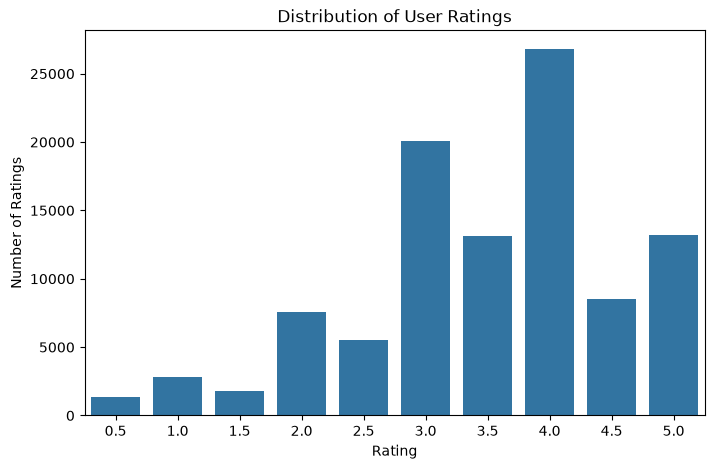

In [97]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=movie_ratings,
    x="rating"
)

plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

In [98]:
movie_ratings["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [99]:
ratings_per_user = (
    movie_ratings
    .groupby("userId")
    .size()
)

ratings_per_user.describe()

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

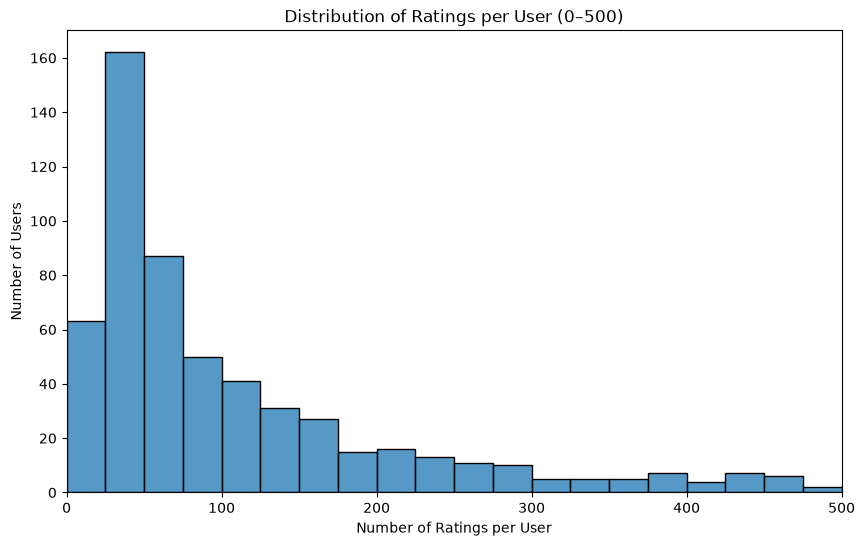

In [100]:
plt.figure(figsize=(10, 6))

sns.histplot(
    ratings_per_user,
    bins=range(0, 525, 25)
)

plt.xlim(0, 500)

plt.title("Distribution of Ratings per User (0–500)")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")

plt.show()

In [101]:
print(ratings_per_user.describe())

print(
    "\nUsers with more than 500 ratings:",
    (ratings_per_user > 500).sum()
)

print(
    "Users with more than 1000 ratings:",
    (ratings_per_user > 1000).sum()
)

print(
    "Maximum ratings by one user:",
    ratings_per_user.max()
)

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Users with more than 500 ratings: 43
Users with more than 1000 ratings: 12
Maximum ratings by one user: 2698


The distribution is strongly right-skewed. Most users have rated fewer than 500 movies, while a small number of highly active users have rated considerably more. The visualization is limited to 0–500 ratings to better show the majority of users.

In [102]:
ratings_per_movie = (
    movie_ratings
    .groupby("movieId")
    .size()
)

ratings_per_movie.describe()

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64

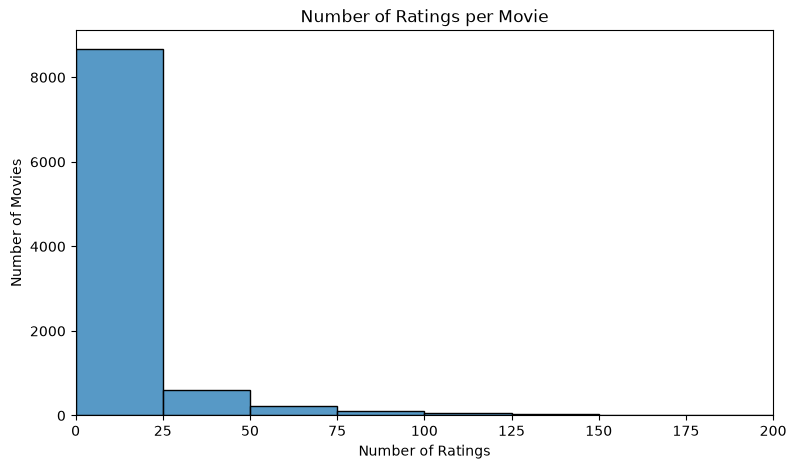

In [103]:
plt.figure(figsize=(9, 5))

sns.histplot(
    ratings_per_movie,
    bins=range(0, 225, 25)
)

plt.xlim(0, 200)

plt.title("Number of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")

plt.show()

In [104]:
most_rated = (
    movie_ratings
    .groupby(["movieId", "title"])
    .agg(
        rating_count=("rating", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .sort_values(
        "rating_count",
        ascending=False
    )
    .head(15)
)

most_rated

,movieId,title,rating_count,average_rating
314,356,Forrest Gump (1994),329,4.164134
277,318,"Shawshank Redemption, The (1994)",317,4.429022
257,296,Pulp Fiction (1994),307,4.197068
510,593,"Silence of the Lambs, The (1991)",279,4.161290
1938,2571,"Matrix, The (1999)",278,4.192446
224,260,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,480,Jurassic Park (1993),238,3.750000
97,110,Braveheart (1995),237,4.031646
507,589,Terminator 2: Judgment Day (1991),224,3.970982
461,527,Schindler's List (1993),220,4.225000


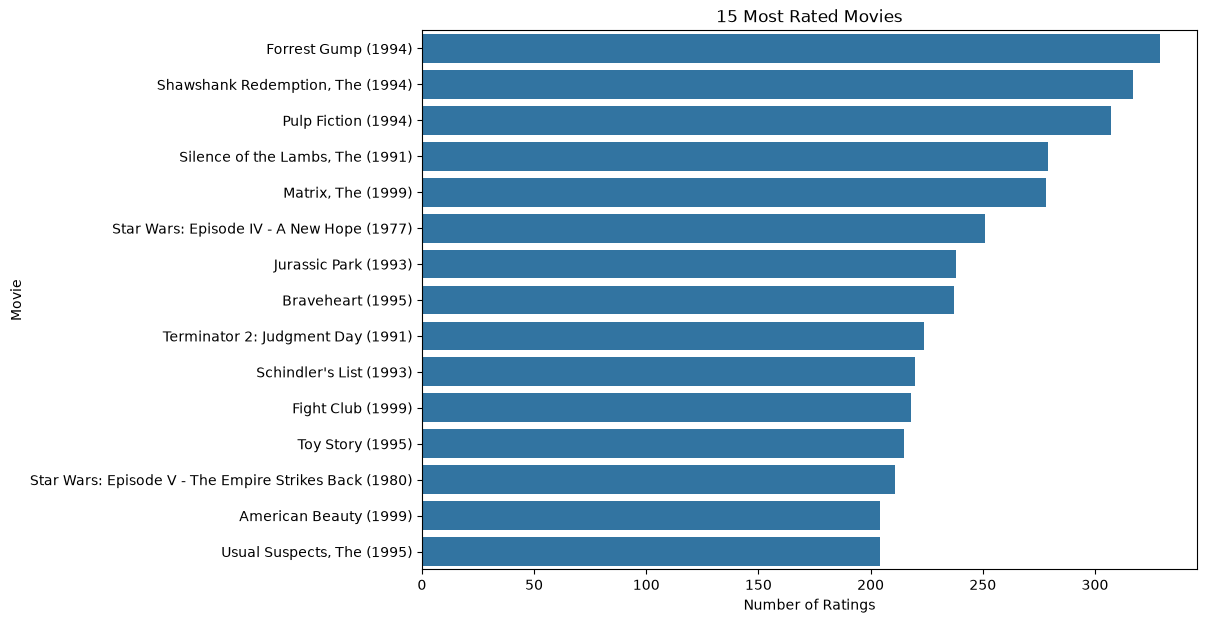

In [105]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=most_rated,
    x="rating_count",
    y="title"
)

plt.title("15 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.show()

In [106]:
movie_summary = (
    movie_ratings
    .groupby(["movieId", "title"])
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

popular_movies = movie_summary[
    movie_summary["rating_count"] >= 50
]

top_rated = (
    popular_movies
    .sort_values(
        "average_rating",
        ascending=False
    )
    .head(15)
)

top_rated

,movieId,title,average_rating,rating_count
277,318,"Shawshank Redemption, The (1994)",4.429022,317
659,858,"Godfather, The (1972)",4.289062,192
2224,2959,Fight Club (1999),4.272936,218
974,1276,Cool Hand Luke (1967),4.271930,57
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
686,904,Rear Window (1954),4.261905,84
921,1221,"Godfather: Part II, The (1974)",4.259690,129
6298,48516,"Departed, The (2006)",4.252336,107
913,1213,Goodfellas (1990),4.250000,126
694,912,Casablanca (1942),4.240000,100


In [107]:
genre_data = movie_ratings.copy()

genre_data["genre"] = (
    genre_data["genres"]
    .str.split("|")
)

genre_data = genre_data.explode(
    "genre"
)

In [108]:
genre_counts = (
    genre_data
    .groupby("genre")
    .size()
    .sort_values(
        ascending=False
    )
)

genre_counts

genre
Drama                 41928
Comedy                39053
Action                30635
Thriller              26452
Adventure             24161
Romance               18124
Sci-Fi                17243
Crime                 16681
Fantasy               11834
Children               9208
Mystery                7674
Horror                 7291
Animation              6988
War                    4859
IMAX                   4145
Musical                4138
Western                1930
Documentary            1219
Film-Noir               870
(no genres listed)       47
dtype: int64

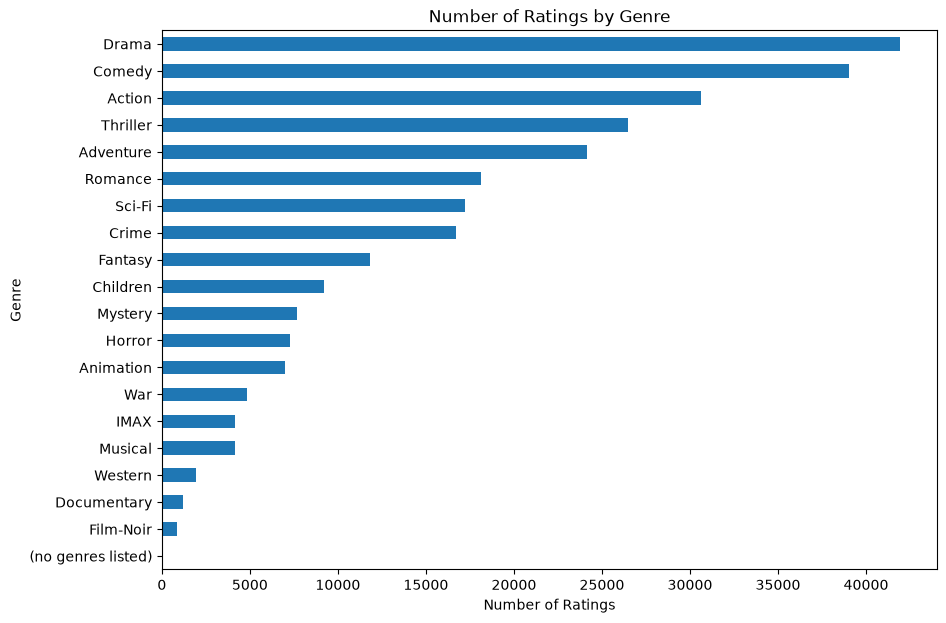

In [109]:
plt.figure(figsize=(10, 7))

genre_counts.sort_values().plot(
    kind="barh"
)

plt.title("Number of Ratings by Genre")
plt.xlabel("Number of Ratings")
plt.ylabel("Genre")

plt.show()

In [110]:
genre_ratings = (
    genre_data
    .groupby("genre")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .sort_values(
        "average_rating",
        ascending=False
    )
)

genre_ratings

,average_rating,rating_count
genre,,
Film-Noir,3.920115,870
War,3.808294,4859
Documentary,3.797785,1219
Crime,3.658294,16681
Drama,3.656184,41928
Mystery,3.632460,7674
Animation,3.629937,6988
IMAX,3.618335,4145
Western,3.583938,1930


In [111]:
example_user = 1

user_genre_profile = (
    genre_data[
        genre_data["userId"] == example_user
    ]
    .groupby("genre")
    .agg(
        movies_rated=("movieId", "count"),
        average_rating=("rating", "mean")
    )
    .sort_values(
        ["average_rating", "movies_rated"],
        ascending=False
    )
)

user_genre_profile

,movies_rated,average_rating
genre,,
Film-Noir,1,5.000000
Animation,29,4.689655
Musical,22,4.681818
Children,42,4.547619
Drama,68,4.529412
War,22,4.500000
Adventure,85,4.388235
Crime,45,4.355556
Action,90,4.322222


Rather than manually assigning preferences, genre preferences can be inferred from actual user ratings.
The next two charts satisfy the user-level visualization requirements.
Multi-genre movies contribute once to each listed genre.

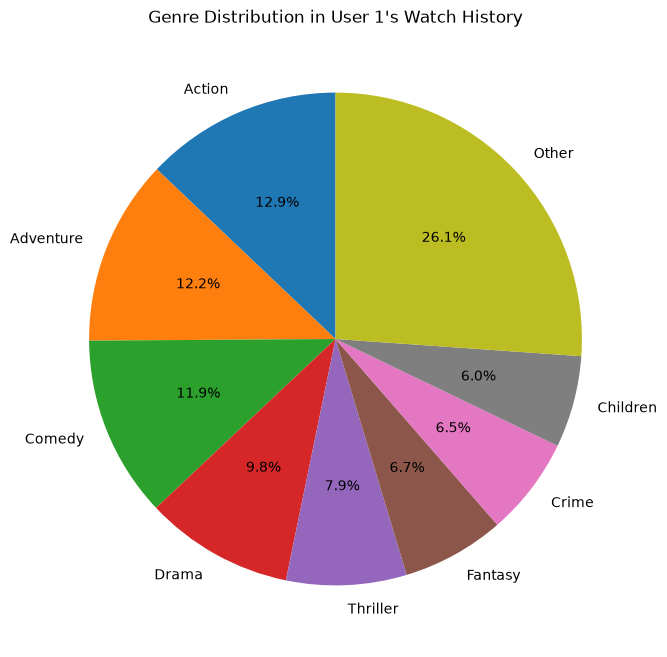

In [112]:
# Count the example user's watched genres; group the long tail so the pie
# chart remains readable.
user_genre_counts = (
    genre_data.loc[genre_data["userId"] == example_user, "genre"]
    .value_counts()
)

pie_counts = user_genre_counts.head(8).copy()
other_count = user_genre_counts.iloc[8:].sum()
if other_count:
    pie_counts.loc["Other"] = other_count

plt.figure(figsize=(8, 8))
pie_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title(f"Genre Distribution in User {example_user}'s Watch History")
plt.ylabel("")
plt.show()

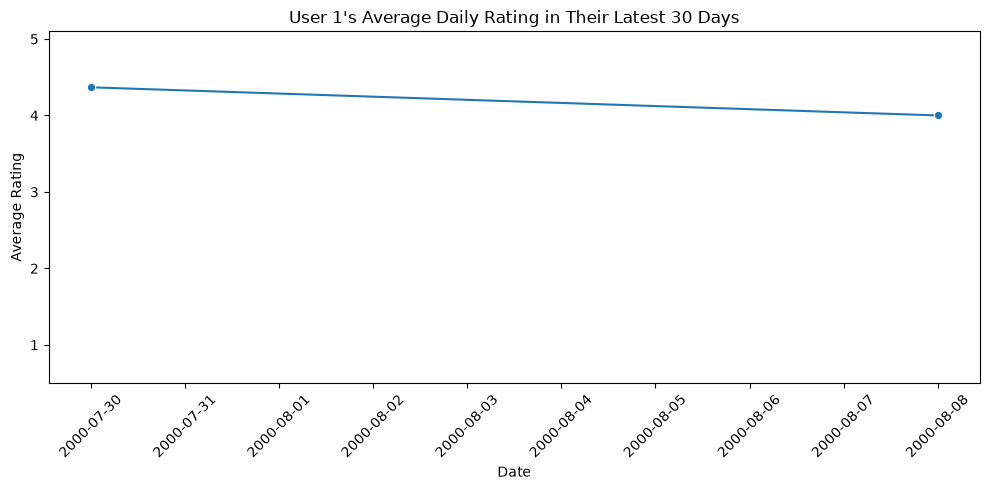

In [113]:
# Use the user's latest recorded date as the end of the 30-day window,
# because MovieLens timestamps are historical rather than live events.
user_timeline = movie_ratings.loc[
    movie_ratings["userId"] == example_user,
    ["watch_date", "rating"]
].dropna().sort_values("watch_date")

window_end = user_timeline["watch_date"].max()
window_start = window_end - pd.Timedelta(days=30)
recent_daily_ratings = (
    user_timeline[user_timeline["watch_date"] >= window_start]
    .assign(date=lambda frame: frame["watch_date"].dt.date)
    .groupby("date", as_index=False)["rating"]
    .mean()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=recent_daily_ratings, x="date", y="rating", marker="o")
plt.ylim(0.5, 5.1)
plt.title(f"User {example_user}'s Average Daily Rating in Their Latest 30 Days")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [114]:
user_genre_matrix = (
    genre_data
    .pivot_table(
        index="userId",
        columns="genre",
        values="rating",
        aggfunc="mean"
    )
)

user_genre_matrix.head()

genre,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
1,NaN,4.322222,4.388235,4.689655,4.547619,4.277108,4.355556,NaN,4.529412,4.297872,5.0,3.470588,NaN,4.681818,4.166667,4.307692,4.225000,4.145455,4.500000,4.285714
2,NaN,3.954545,4.166667,NaN,NaN,4.000000,3.800000,4.333333,3.882353,NaN,NaN,3.000000,3.750000,NaN,4.000000,4.500000,3.875000,3.700000,4.500000,3.500000
3,NaN,3.571429,2.727273,0.500000,0.500000,1.000000,0.500000,NaN,0.750000,3.375000,NaN,4.687500,NaN,0.500000,5.000000,0.500000,4.200000,4.142857,0.500000,NaN
4,NaN,3.320000,3.655172,4.000000,3.800000,3.509615,3.814815,4.000000,3.483333,3.684211,4.0,4.250000,3.000000,4.000000,3.478261,3.379310,2.833333,3.552632,3.571429,3.800000
5,NaN,3.111111,3.250000,4.333333,4.111111,3.466667,3.833333,NaN,3.800000,4.142857,NaN,3.000000,3.666667,4.400000,4.000000,3.090909,2.500000,3.555556,3.333333,3.000000


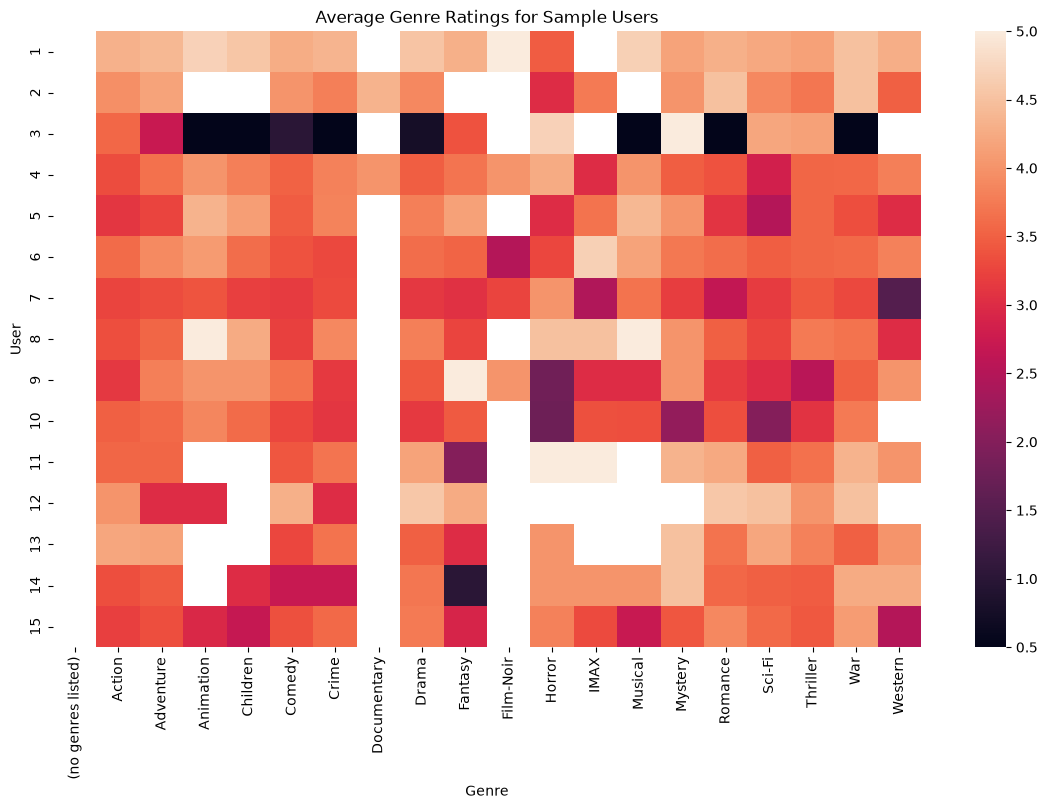

In [115]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    user_genre_matrix.head(15),
    annot=False
)

plt.title("Average Genre Ratings for Sample Users")
plt.xlabel("Genre")
plt.ylabel("User")

plt.show()

In [116]:
rating_matrix = movie_ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

In [117]:
rating_matrix.shape

(610, 9724)

In [118]:
total_possible_ratings = (
    rating_matrix.shape[0]
    * rating_matrix.shape[1]
)

actual_ratings = rating_matrix.notna().sum().sum()

sparsity = (
    1 - actual_ratings / total_possible_ratings
) * 100

print(
    f"Rating matrix sparsity: "
    f"{sparsity:.2f}%"
)

Rating matrix sparsity: 98.30%


Most users have rated only a small fraction of all available movies. Therefore, Pearson similarity should only be calculated between users who share enough commonly rated movies.

In [119]:
user1 = 1
user2 = 2

user1_movies = set(
    movie_ratings.loc[
        movie_ratings["userId"] == user1,
        "movieId"
    ]
)

user2_movies = set(
    movie_ratings.loc[
        movie_ratings["userId"] == user2,
        "movieId"
    ]
)

common_movies = (
    user1_movies
    & user2_movies
)

print(
    f"Users {user1} and {user2} "
    f"have {len(common_movies)} movies in common."
)

Users 1 and 2 have 2 movies in common.


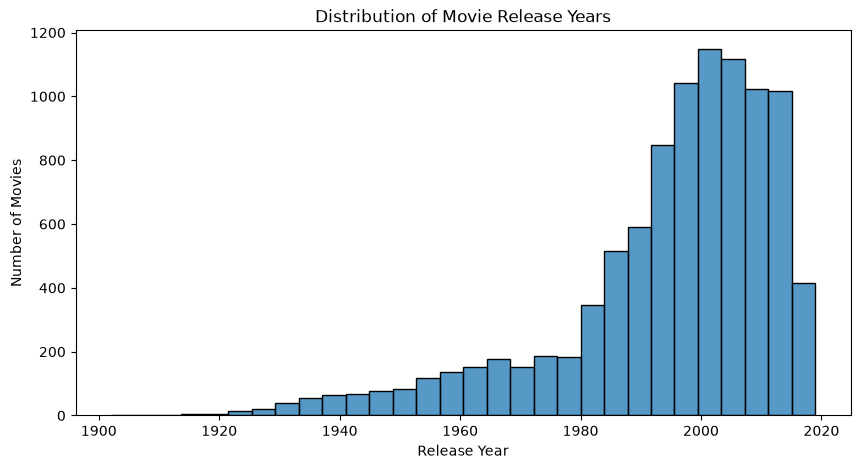

In [120]:
movie_level = (
    movie_ratings
    .drop_duplicates("movieId")
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=movie_level,
    x="release_year",
    bins=30
)

plt.title("Distribution of Movie Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

In [121]:
movie_comparison = (
    movie_ratings
    .groupby("movieId")
    .agg(
        movielens_rating=("rating", "mean"),
        tmdb_rating=("tmdb_rating", "first"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

movie_comparison = movie_comparison[
    movie_comparison["rating_count"] >= 20
]

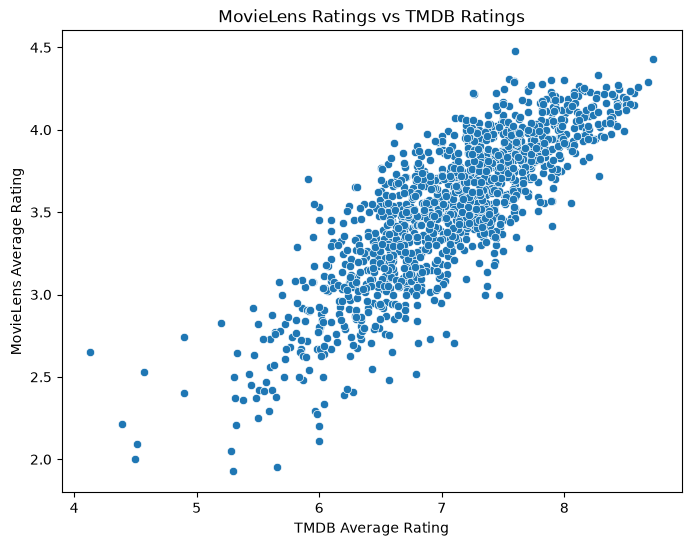

In [122]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=movie_comparison,
    x="tmdb_rating",
    y="movielens_rating"
)

plt.title(
    "MovieLens Ratings vs TMDB Ratings"
)

plt.xlabel("TMDB Average Rating")
plt.ylabel("MovieLens Average Rating")

plt.show()

In [123]:
director_summary = (
    movie_ratings[
        movie_ratings["director"].notna()
    ]
    .groupby("director")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count"),
        movies=("movieId", "nunique")
    )
)

director_summary = director_summary[
    director_summary["rating_count"] >= 100
]

director_summary.sort_values(
    "average_rating",
    ascending=False
).head(15)

,average_rating,rating_count,movies
director,,,
Frank Darabont,4.308628,452,4
Tony Kaye,4.215385,130,2
Michael Curtiz,4.199153,118,9
David Lean,4.168067,119,7
Terry Jones | Terry Gilliam,4.161765,136,1
Akira Kurosawa,4.148000,125,14
George Cukor,4.120000,100,14
Richard Marquand,4.118227,203,2
Sergio Leone,4.096154,182,6


## EDA Summary

The exploratory analysis showed several important patterns in the MovieLens dataset:

- The dataset contains 100,836 ratings from 610 users across 9,724 movies.
- Ratings are concentrated toward the higher end of the scale, suggesting users generally rate movies they enjoy.
- The number of ratings per user is strongly right-skewed. Most users rated relatively few movies, while a small number of highly active users contributed many ratings.
- Movie popularity is also uneven, with a relatively small number of movies receiving a large share of the ratings.
- Genre preferences differ noticeably between users, supporting the idea of building personalized user profiles.
- The user-movie rating matrix is sparse, meaning most users have rated only a small fraction of all available movies. This makes overlap between users important when applying Pearson correlation.
- TMDB enrichment provided director and additional metadata for almost all movies, allowing director preferences and movie metadata to be incorporated into the recommendation system.

These findings support the use of multiple recommendation approaches. Genre and director information can be used for content-based recommendations, while shared ratings can be used to identify similar users with Pearson correlation. User genre profiles can also be used for k-means clustering to identify groups with similar preferences.

The next step is to create user preference features that can be used by the recommendation engine.

In [ ]:
# Save to the shared processed-data directory used by notebooks 02 and 03.
NOTEBOOK_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
processed_path = NOTEBOOK_PROCESSED_DIR / "movie_ratings.csv"

movie_ratings.to_csv(
    processed_path,
    index=False
)

print(
    f"Processed dataset saved to: "
    f"{processed_path}"
)